<a href="https://colab.research.google.com/github/robertbarcik/genai-in-python-tutorial/blob/main/2_basic_project_examples/2_basic_model_usage/2_basic_model_usage.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Basic OpenAI API Usage

By the end of this notebook, you'll be able to:

1. **Content Moderation** - Check user messages for inappropriate content
2. **Text Generation** - Draft responses, summarize documents, assist with troubleshooting
3. **Audio Features** - Convert text to speech and transcribe audio
4. **Image Generation** - Create simple visuals for documentation
5. **Vision Analysis** - Analyze error screenshots and hardware images
6. **Cost Management** - Use the most cost-effective models for each task

---

## What is an API?

An **API (Application Programming Interface)** is a way for different software programs to communicate with each other.

### What is an API Endpoint?

An **endpoint** is a specific function or service the API provides. For example:
- `/v1/chat/completions` - Text generation endpoint
- `/v1/moderations` - Content moderation endpoint
- `/v1/images/generations` - Image generation endpoint

Each endpoint has a specific purpose and accepts different parameters.

### Request/Response Structure

API communication follows a simple pattern:

1. **Request**: You send data to the API
   - Headers (authentication, content type)
   - Parameters (instructions, settings)
   - Body (the actual data to process)

2. **Response**: The API sends back results
   - Status code (200 = success, 429 = rate limit, etc.)
   - Data (the result you requested)
   - Metadata (usage stats, IDs, etc.)

### ⚠️ Important Concepts

**Rate Limits**: APIs limit how many requests you can make per minute/day to prevent abuse. If you exceed these limits, you'll receive an error.

**Costs**: Most API calls cost money based on usage:
- Text models charge per "token" (roughly 4 characters)
- Image models charge per image generated
- Audio models charge per character (TTS) or per minute (transcription)

**Security Best Practice**: ⚠️ **NEVER hardcode API keys in production code!** Always use environment variables, secrets management, or secure configuration systems.

---

Let's get started!

---

#  Setup

First, we need to configure your OpenAI API key and install required libraries.

##  Install Dependencies

We'll install three libraries:
- **openai**: Official OpenAI Python client for API access
- **pillow**: Image processing library for displaying and manipulating images
- **requests**: HTTP library for downloading files from URLs

In [1]:
!pip install -q openai==2.28.0 pillow==11.3.0 requests==2.32.4


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


##  API Key Configuration

You have two methods to provide your API key:

**Method 1 (Recommended)**: Use Colab Secrets
1. Click the 🔑 icon in the left sidebar
2. Click "Add new secret"
3. Name: `OPENAI_API_KEY`
4. Value: Your OpenAI API key
5. Enable notebook access

**Method 2 (Fallback)**: Manual input when prompted

Run the cell below to configure authentication:

In [2]:
import os

# Configure OpenAI API key
# Method 1: Try to get API key from Colab secrets (recommended)
try:
    from google.colab import userdata
    OPENAI_API_KEY = userdata.get('OPENAI_API_KEY')
    print("✅ API key loaded from Colab secrets")
except:
    import os
    if os.environ.get('OPENAI_API_KEY'):
        OPENAI_API_KEY = os.environ.get('OPENAI_API_KEY')
        print("✅ API key loaded from environment variable")
    else:
        # Method 2: Manual input (fallback)
        from getpass import getpass
        print("💡 To use Colab secrets: Go to 🔑 (left sidebar) → Add new secret → Name: OPENAI_API_KEY")
        OPENAI_API_KEY = getpass("Enter your OpenAI API Key: ")

# Set the API key as an environment variable
os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

# Validate that the API key is set
if not OPENAI_API_KEY or OPENAI_API_KEY.strip() == "":
    raise ValueError("❌ ERROR: No API key provided!")

print("✅ Authentication configured!")

# Configure which OpenAI model to use
# Options: "gpt-4o", "gpt-4o-mini", "gpt-4-turbo", "gpt-3.5-turbo", "gpt-5-nano", etc.
OPENAI_MODEL = "gpt-5-nano"  # Using gpt-5-nano for cost efficiency
print(f"Selected Model: {OPENAI_MODEL}")

✅ API key loaded from environment variable
✅ Authentication configured!
Selected Model: gpt-5-nano


##  Initialize OpenAI Client

Now let's create a client instance to interact with the OpenAI API:

In [3]:
from openai import OpenAI

# Initialize the OpenAI client
client = OpenAI(api_key=OPENAI_API_KEY)

print("✅ OpenAI client initialized successfully!")

✅ OpenAI client initialized successfully!


---

#  Content Moderation

## What it Does

The moderation API detects potentially harmful or inappropriate content in text. It checks for:
- Hate speech
- Harassment and bullying
- Violence and graphic content
- Self-harm content
- Sexual content
- And more...

## When to Use It

Use moderation **before** processing user-submitted content:
- Support ticket messages
- Chat messages
- Email content
- User feedback forms

## Why It Matters

1. **Protects your API account** - OpenAI can suspend accounts that process harmful content
2. **Ensures safe interactions** - Filters out inappropriate content before your team sees it
3. **FREE to use** - The moderation API is completely free for OpenAI users!

## Key Parameters

- **input**: The text to check (string or array of strings)

**Response contains:**
- **flagged**: Boolean indicating if content violates policies
- **categories**: Dictionary of specific violation types (hate, violence, etc.)
- **category_scores**: Confidence scores (0-1) for each category

---

## Practical Example: Checking Customer Messages

In [4]:
# Example 1: Frustrated but appropriate customer message
customer_message_1 = """This is absolutely ridiculous! Your service is terrible
and I'm furious about this issue with my account!"""

# Send the message to the moderation API for safety check
response = client.moderations.create(input=customer_message_1)

# The response contains a list of results (one per input message)
result = response.results[0]

print("Moderation Check Results:")
print(f"Is Flagged: {result.flagged}")
print(f"\nCategory Flags:")
# result.categories is an iterable of (category_name, is_flagged) pairs
# We loop through to find which specific categories were flagged
for category, flagged in result.categories:
    if flagged:
        print(f"  ⚠️ {category}: {flagged}")

if not result.flagged:
    print("\n✅ Message is safe to process")

Moderation Check Results:
Is Flagged: False

Category Flags:

✅ Message is safe to process


In [5]:
# Example 2: Inappropriate message (DO NOT USE IN PRODUCTION)
# This example demonstrates what gets flagged
inappropriate_message = """I hate your company and all your stupid employees.
You're all idiots and deserve to lose your jobs."""

response = client.moderations.create(input=inappropriate_message)
result = response.results[0]

print("Moderation Check Results:")
print(f"Is Flagged: {result.flagged}")
print(f"\nCategory Flags:")
# Check which specific categories were violated
for category, flagged in result.categories:
    if flagged:
        print(f"  ⚠️ {category}: {flagged}")

if result.flagged:
    print("\n🚫 Message contains inappropriate content - DO NOT process with API")

Moderation Check Results:
Is Flagged: True

Category Flags:
  ⚠️ harassment: True

🚫 Message contains inappropriate content - DO NOT process with API


## Reusable Function

Let's create a simple function you can use in your projects:

In [6]:
def check_content_safety(text):
    """
    Check if text content is safe to process.

    Args:
        text (str): The text to check

    Returns:
        dict: Contains 'is_safe' boolean and 'flagged_categories' list
    """
    response = client.moderations.create(input=text)
    result = response.results[0]

    # Get all flagged categories
    flagged_categories = [category for category, flagged in result.categories if flagged]

    return {
        "is_safe": not result.flagged,
        "flagged_categories": flagged_categories
    }

# Test the function
test_message = "My printer won't work and I need help urgently!"
safety_check = check_content_safety(test_message)

print(f"Is safe: {safety_check['is_safe']}")
if safety_check['flagged_categories']:
    print(f"Flagged for: {', '.join(safety_check['flagged_categories'])}")
else:
    print("No violations detected ✅")

Is safe: True
No violations detected ✅


## Common Pitfalls

1. **Not checking all category flags individually** - Just checking `flagged` isn't enough; sometimes you need to know *what* was flagged

2. **Forgetting to check moderation before sending to main API** - Always moderate user content first to protect your account

3. **Over-relying on moderation** - The API is very good but not 100% perfect. Consider it as a helpful filter, not absolute protection

4. **Not handling edge cases** - Very short messages or special characters might behave unexpectedly

---

---

#  Text Generation

## What it Does

Text generation models create human-like text responses using advanced language models. They can:
- Answer questions
- Draft responses
- Summarize content
- Provide troubleshooting guidance
- Explain technical concepts

## When to Use It

- **Drafting support ticket responses** - Save time with AI-generated first drafts
- **Summarizing documentation** - Condense long technical docs into key points
- **Troubleshooting assistance** - Generate step-by-step diagnostic procedures
- **Knowledge base creation** - Turn technical info into user-friendly content

## Cost Implications

Text generation is charged **per token**.

**What's a token?** Roughly 4 characters or 0.75 words. For example:
- "Hello" = 1 token
- "Hello, how are you?" = 5 tokens
- 100 words ≈ 133 tokens

You're charged for **both input and output tokens**.

## Context Window

Models have limits on how much text they can process at once (input + output). For example:
- `gpt-5-nano`: 128K tokens (~96,000 words)
- `gpt-3.5-turbo`: 16K tokens (~12,000 words)

## Key Parameters for gpt-5-nano (Responses API)

**Important**: gpt-5-nano uses the **Responses API**, not the Chat Completions API!

- **model**: "gpt-5-nano" (one of the cheapest models)
- **input**: Your prompt or question (string)
- **text**: Dictionary with optional settings:
  - **verbosity**: "low", "medium", or "high" - controls response length and detail
    - "low": Brief, concise responses
    - "medium": Balanced responses (default)
    - "high": Detailed, comprehensive responses

**Response structure**:
- Use `response.output_text` to get the generated text
- Use `response.usage.total_tokens` for token count

**Example**:
```python
response = client.responses.create(
    model="gpt-5-nano",
    input="Your prompt here",
    text={"verbosity": "high"}
)

output = response.output_text
```



---

## Example 1: Drafting a Support Ticket Response

In [7]:
# Scenario: User reports printer not working
user_ticket = """My printer won't print anything. I tried turning it off and on
but nothing works. I need to print reports for a meeting in 30 minutes."""

# System prompt defines the assistant's role and behavior
system_prompt = """You are an IT support assistant. Respond professionally,
empathetically, and provide clear troubleshooting steps. Keep responses concise but thorough."""

# Combine system prompt with user message
full_input = f"{system_prompt}\n\nUser message: {user_ticket}"

# Make the API call using Responses API
response = client.responses.create(
    model=OPENAI_MODEL,
    input=full_input,
    text={"verbosity": "high"}
)

# Extract the response
draft_response = response.output_text

print("Draft Response:")
print(draft_response)
print(f"\nTokens used: {response.usage.total_tokens}")

Draft Response:
I’m sorry you’re in this spot—let’s get you printing fast. I’ll give you quick, concrete steps. Please tell me your setup if you can: what OS you're on (Windows or Mac), how the printer is connected (USB, Ethernet, or Wi‑Fi), and any error messages or lights you’re seeing.

Start with these fast checks (should take 5–10 minutes)

1) Confirm printer status and queue
- Look at the printer display or lights: any error codes or paper jams?
- On your computer:
  - Windows: Settings > Devices > Printers & scanners. Open your printer’s queue. If it shows Offline or stuck documents, cancel all, then try Print again.
  - Mac: System Settings > Printers & Scanners > select printer > Open Print Queue. Cancel all documents.

2) Make sure the printer is online and selected
- Windows: ensure the printer is set as default (right-click > Set as default). In the queue, choose Resume or Use Printer Online if shown as Offline.
- Mac: ensure the printer is not paused; if needed, remove and

##  Example 2: Summarizing Technical Documentation

In [8]:
# Scenario: Summarize a long technical document
long_technical_doc = """
VPN Configuration Guide:

To establish a secure VPN connection, users must first ensure they have the latest
VPN client installed (version 8.2 or higher). The installation package can be
downloaded from the company portal under Software > Security Tools.

Once installed, launch the VPN client and enter your corporate credentials.
The username should be in the format: firstname.lastname@company.com.
Use your standard Windows password.

After successful authentication, select the appropriate VPN gateway from the dropdown:
- US-EAST-01: For users in North America
- EU-WEST-01: For users in Europe
- ASIA-PAC-01: For users in Asia Pacific

Click Connect and wait for the status indicator to turn green. This typically takes
15-30 seconds. Once connected, you'll have access to internal resources including
file shares, internal websites, and database servers.

If you experience connection issues, first verify your internet connection is stable.
Then check if your antivirus software is blocking the VPN client. Common antivirus
programs that may interfere include McAfee and Norton. Add an exception for the
VPN client executable if necessary.

For persistent issues, contact IT support with your error message and the VPN.log
file located in C:\\Program Files\\CompanyVPN\\logs\\.
"""

system_prompt = "Summarize this technical documentation in 3-4 bullet points for end users."

# Combine system prompt with document
full_input = f"{system_prompt}\n\n{long_technical_doc}"

response = client.responses.create(
    model=OPENAI_MODEL,
    input=full_input,
    text={"verbosity": "medium"}  # Using medium for concise summary
)

summary = response.output_text

print("📋 Summary:")
print(summary)
print(f"\n Tokens used: {response.usage.total_tokens}")
print(f"   Input: {response.usage.input_tokens}, Output: {response.usage.output_tokens}")

📋 Summary:
- Install the latest VPN client (version 8.2 or higher) from the company portal (Software > Security Tools), then launch and sign in with firstname.lastname@company.com using your Windows password.
- In the client, select the gateway by region: US-EAST-01 (North America), EU-WEST-01 (Europe), or ASIA-PAC-01 (Asia Pacific); click Connect and wait ~15–30 seconds for the status to turn green.
- Once connected, you’ll have access to internal resources such as file shares, internal websites, and databases.
- If you have issues, verify your internet connection and that your antivirus isn’t blocking the VPN (common programs include McAfee and Norton; add an exception for the VPN executable if needed). For persistent problems, contact IT with the error message and the VPN.log file at C:\Program Files\CompanyVPN\logs\.

 Tokens used: 1089
   Input: 282, Output: 807


##  Example 3: Troubleshooting Assistant

In [9]:
# Scenario: User describes an error
user_description = "I keep getting 'Access Denied' when trying to open the shared drive."

system_prompt = """You are a troubleshooting assistant. Provide step-by-step diagnostic steps.
Number each step clearly. Focus on the most common causes first."""

# Combine system prompt with user description
full_input = f"{system_prompt}\n\nUser issue: {user_description}"

response = client.responses.create(
    model=OPENAI_MODEL,
    input=full_input,
    text={"verbosity": "high"}
)

troubleshooting_steps = response.output_text

print(" Troubleshooting Steps:")
print(troubleshooting_steps)

 Troubleshooting Steps:
Here’s a clear, step-by-step diagnostic plan to troubleshoot "Access Denied" when opening a shared drive. I’ll start with the most common causes and move to less common ones. If you can’t complete a step or the step yields an error, tell me the exact message and we’ll adjust.

1) Confirm exactly where the denial happens
- Ask yourself: Is this a mapped network drive (letter like Z:) or a direct UNC path (\\server\share) you’re opening?
- Note when the error occurs (on login, when opening a specific folder, or when mapping the drive).
- Why: the fix path changes depending on mapped drive vs. UNC access and your OS.

2) Check basic network connectivity to the file server
- On your PC, ping the server name: ping SERVERNAME
- If that fails, try the numeric IP: ping 192.168.x.y
- If DNS/name resolution is failing, you may have a DNS issue or VPN requirement; try tracert SERVERNAME to see where it stops.
- Why: If you can’t reach the server at all, it’s not a permissi

##  Error Handling

API calls can fail for various reasons: network issues, invalid API key, rate limits, etc. The function below wraps the API call in a `try/except` block so that instead of crashing, it returns a dictionary with either the successful response or an error message. This makes it easy to check `result["success"]` and handle failures gracefully in your code.

Always wrap API calls in try/except blocks to handle potential errors:

In [10]:
def generate_response_safely(user_message, system_message="You are a helpful IT assistant."):
    """
    Generate a response with proper error handling.

    Args:
        user_message (str): The user's input
        system_message (str): System prompt for the assistant

    Returns:
        dict: Contains 'success' boolean, 'response' text, and optional 'error' message
    """
    try:
        # Combine system prompt with user message
        full_input = f"{system_message}\n\nUser: {user_message}"

        response = client.responses.create(
            model=OPENAI_MODEL,
            input=full_input,
            text={"verbosity": "high"}
        )

        return {
            "success": True,
            "response": response.output_text,
            "tokens_used": response.usage.total_tokens
        }

    except Exception as e:
        return {
            "success": False,
            "error": str(e),
            "response": None
        }

# Test the function
result = generate_response_safely("How do I reset my password?")

if result["success"]:
    print("✅ Response generated successfully")
    print(result["response"])
else:
    print(f"❌ Error: {result['error']}")

✅ Response generated successfully
Sure—I'd be happy to help. Which password are you trying to reset? A specific online service (like Google, Microsoft, Apple, Facebook, etc.), or a password for a device (Windows PC or Mac)? If you’re not sure, I can give you the general steps and you can tell me which one fits.

In the meantime, here are the most common paths you’ll take:

General method for online accounts (Google, Microsoft, Apple, etc.)
- Go to the service’s sign-in page.
- Click “Forgot password?” or “Can’t access your account?”
- Enter your username or email address.
- Choose a recovery method (send a code to your backup email or phone, use an authentication app, or answer security questions).
- Enter the code or follow the link to reset.
- Create a new password (choose something strong: at least 12 characters, mix of letters, numbers, and symbols; don’t reuse old passwords).
- Sign in with the new password and update any saved passwords (password manager, browser, etc.).
- If you

##  Common Pitfalls

1. **Vague prompts leading to generic responses**
   - ❌ Bad: "Help with printer"
   - ✅ Good: "Provide step-by-step troubleshooting for a printer that won't print"

2. **Not controlling response length**
   - Use the `verbosity` parameter ("low", "medium", "high") to control response length and cost
   - "low" produces shorter, cheaper responses; "high" produces detailed ones

3. **Forgetting to handle API errors**
   - Always use try/except blocks
   - Common errors: rate limits, invalid API key, network issues

4. **Not using system prompts effectively**
   - System prompts set the behavior and tone
   - Be specific about desired output format and style

---

---

# Audio Features (Text-to-Speech & Transcription)

## What it Does

OpenAI provides two audio capabilities:
1. **Text-to-Speech (TTS)**: Convert text into natural-sounding speech
2. **Transcription**: Convert audio recordings into text

## When to Use It

**Text-to-Speech:**
- Creating audio guides for common procedures
- Accessibility features for visually impaired users
- Automated phone system messages
- Training materials

**Transcription:**
- Converting support call recordings to text
- Creating searchable records of meetings
- Documenting verbal troubleshooting sessions

## Models

**TTS Models:**
- `tts-1`: Faster, cheaper, good quality
- `tts-1-hd`: Higher quality, more expensive

**Transcription Model:**
- `whisper-1`: OpenAI's speech recognition model

---

## Part A: Text-to-Speech

### Key Parameters

- **model**: `"tts-1"` (cheaper, faster) or `"tts-1-hd"` (higher quality)
- **voice**: Choose from 6 voices:
  - `alloy`: Neutral, balanced
  - `echo`: Male, clear
  - `fable`: Male, expressive
  - `onyx`: Male, deep
  - `nova`: Female, energetic
  - `shimmer`: Female, soft
- **input**: Text to convert (max 4096 characters)
- **speed**: 0.25 to 4.0 (default 1.0)

###  Practical Example: Create Password Reset Audio Guide

In [11]:
# Text for our audio guide
password_reset_guide = """
Welcome to the password reset guide. Here are the steps:

First, go to the login page and click 'Forgot Password'.

Second, enter your work email address.

Third, check your email for a reset link. This may take a few minutes.

Finally, click the link and create a new password.

Remember: your password must be at least 8 characters with numbers and symbols.

If you need further assistance, contact the IT help desk. Thank you.
"""

# Generate speech
print("🎙️ Generating audio...")
response = client.audio.speech.create(
    model="tts-1",  # Using cheaper model
    voice="nova",   # Female, energetic voice
    input=password_reset_guide,
    speed=1.0
)

# Save the audio file
audio_file_path = "./password_reset_guide.mp3"
response.stream_to_file(audio_file_path)

print(f"✅ Audio saved to: {audio_file_path}")
print("\n▶️ You can play it using the file browser on the left sidebar")

🎙️ Generating audio...


✅ Audio saved to: ./password_reset_guide.mp3

▶️ You can play it using the file browser on the left sidebar


/var/folders/bh/p1vsc7wx553c75bl6f43y79w0000gn/T/ipykernel_81511/2623123186.py:29: DeprecationWarning: Due to a bug, this method doesn't actually stream the response content, `.with_streaming_response.method()` should be used instead
  response.stream_to_file(audio_file_path)


In [12]:
# Display audio player in notebook
from IPython.display import Audio, display

display(Audio(audio_file_path))

## Part B: Transcription (Speech-to-Text)

###  Key Parameters

- **model**: `"whisper-1"` (OpenAI's speech recognition model)
- **file**: Audio file to transcribe (max 25MB)
- **language**: Optional ISO-639-1 code (e.g., "en" for English) for better accuracy
- **response_format**: "json", "text", "srt", "vtt", or "verbose_json"

**Supported formats**: mp3, mp4, mpeg, mpga, m4a, wav, webm

###  Practical Example: Transcribe the Audio We Just Created

In [13]:
# Transcribe the password reset guide we just created
print("🎤 Transcribing audio...")

with open(audio_file_path, "rb") as audio_file:
    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=audio_file,
        language="en"  # Specify English for better accuracy
    )

print("✅ Transcription complete!\n")
print("📝 Transcribed Text:")
print(transcript.text)

🎤 Transcribing audio...


✅ Transcription complete!

📝 Transcribed Text:
Welcome to the password reset guide. Here are the steps. First, go to the login page and click forgot password. Second, enter your work email address. Third, check your email for a reset link. This may take a few minutes. Finally, click the link and create a new password. Remember, your password must be at least eight characters with numbers and symbols. If you need further assistance, contact the IT help desk. Thank you.


###  Compare Original vs Transcription

In [14]:
print("=" * 60)
print("COMPARISON: Original Text → Audio → Transcription")
print("=" * 60)

print("\n ORIGINAL TEXT:")
print(password_reset_guide)

print("\n TRANSCRIBED TEXT:")
print(transcript.text)

print("\n Notice how accurate the transcription is!")

COMPARISON: Original Text → Audio → Transcription

 ORIGINAL TEXT:

Welcome to the password reset guide. Here are the steps:

First, go to the login page and click 'Forgot Password'.

Second, enter your work email address.

Third, check your email for a reset link. This may take a few minutes.

Finally, click the link and create a new password.

Remember: your password must be at least 8 characters with numbers and symbols.

If you need further assistance, contact the IT help desk. Thank you.


 TRANSCRIBED TEXT:
Welcome to the password reset guide. Here are the steps. First, go to the login page and click forgot password. Second, enter your work email address. Third, check your email for a reset link. This may take a few minutes. Finally, click the link and create a new password. Remember, your password must be at least eight characters with numbers and symbols. If you need further assistance, contact the IT help desk. Thank you.

 Notice how accurate the transcription is!


## Common Pitfalls

### Text-to-Speech:
1. **Text too long** - Maximum 4096 characters per request. Split longer text into chunks.
2. **Wrong speed settings** - Speed too fast (>1.5) can reduce clarity

### Transcription:
1. **Audio files too large** - Whisper-1 has a 25MB limit. Compress large files first.
2. **Wrong audio format** - Ensure your file is in a supported format (mp3, wav, etc.)
3. **Not specifying language** - Adding the language parameter improves accuracy
4. **Poor audio quality** - Background noise and low volume reduce transcription accuracy
5. **Very long files** - Consider splitting files longer than 30 minutes

---

---

# Image Generation

##  What it Does

The image generation API creates images from text descriptions using DALL-E models. You provide a text prompt, and it generates an original image.

##  When to Use It

- **Quick mockups** - Visualize concepts before creating proper designs
- **Documentation visuals** - Create diagrams and illustrations for guides
- **Training materials** - Generate images for presentations and tutorials
- **Placeholder images** - Quick visuals during development


## Models

- `dall-e-3`: Latest DALL-E model, high quality, better prompt following (recommended)
- `dall-e-2`: Cheaper, good quality, faster

**We'll use DALL-E 3 for better quality and prompt understanding.**

## Key Parameters

- **model**: `"dall-e-3"` (recommended) or `"dall-e-2"`
- **prompt**: Description of the image (max 4000 characters for DALL-E 3)
- **size**: Image dimensions
  - DALL-E 3: `"1024x1024"` (square), `"1792x1024"` (landscape), or `"1024x1792"` (portrait)
  - DALL-E 2: `"256x256"`, `"512x512"`, or `"1024x1024"`
- **quality**: `"standard"` or `"hd"` (DALL-E 3 only, default: "standard")
  - "hd": Creates images with finer details and greater consistency (costs more)
  - "standard": Regular quality, more cost-effective
- **style**: `"vivid"` or `"natural"` (DALL-E 3 only)
  - "vivid": Hyper-real, dramatic images
  - "natural": More natural-looking images
- **n**: Number of images to generate
  - DALL-E 3: **Only supports n=1** (one image per request)
  - DALL-E 2: Supports 1-10 images per request
- **response_format**: `"url"` (default) or `"b64_json"`


---

##  Practical Example: Network Diagram for Documentation

> **Cost note:** DALL-E 3 access varies by account/plan and no longer accepts the `style` parameter on newer API versions. This example uses `gpt-image-1` at `quality="low"` instead, which costs a fraction of a cent per 1024x1024 image and returns image data as base64 (no `url` field).

In [15]:
# Create a simple network diagram
prompt = """A simple network diagram showing a router connected to a firewall,
with three workstations behind it. Clean, technical style with clear labels.
Minimalist and professional. White background."""

print("Generating image...")
print(f"Prompt: {prompt}\n")

response = client.images.generate(
    model="gpt-image-1",   # dall-e-3 requires special account access; gpt-image-1 is the current default
    prompt=prompt,
    size="1024x1024",      # Square format for documentation
    quality="low",         # Low quality for cost efficiency in this demo
    n=1
)

# gpt-image-1 returns base64-encoded image data (no url field)
image_b64 = response.data[0].b64_json
print("Image generated!")
print(f"Base64 payload length: {len(image_b64)} characters")

Generating image...
Prompt: A simple network diagram showing a router connected to a firewall,
with three workstations behind it. Clean, technical style with clear labels.
Minimalist and professional. White background.



Image generated!
Base64 payload length: 973124 characters


Saved to: ./network_diagram.png


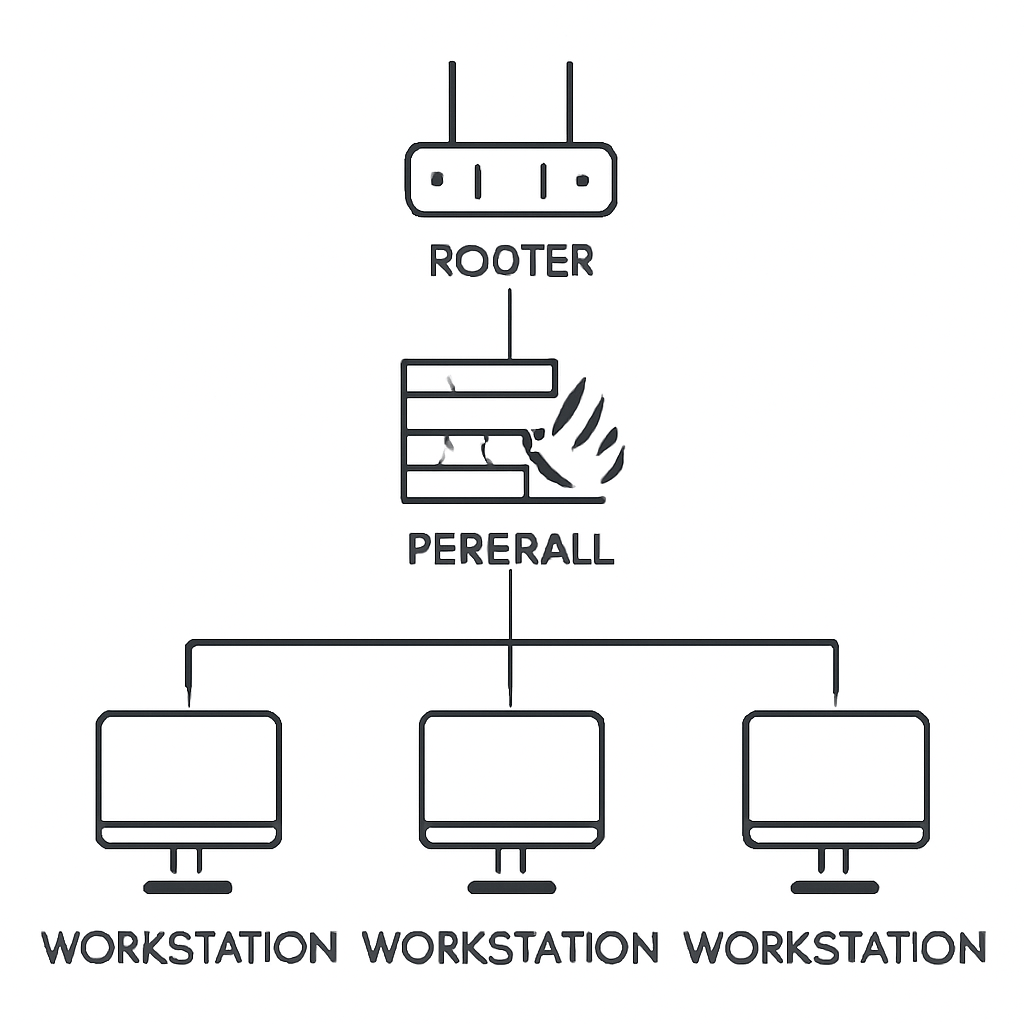

In [16]:
# Decode and display the image
import base64
from PIL import Image
from io import BytesIO

# Decode the base64 image data
image_bytes = base64.b64decode(image_b64)
image = Image.open(BytesIO(image_bytes))

# Save to file
image_path = "./network_diagram.png"
image.save(image_path)
print(f"Saved to: {image_path}")

# Display in notebook
display(image)

---

# Vision (Image Analysis)

##  What it Does

Vision-capable models can "see" and analyze images. They can:
- Describe what's in an image
- Read text from screenshots
- Identify error messages
- Analyze hardware components
- Recognize UI elements


##  Models

- `gpt-5-nano`: Cost-efficient vision model (recommended for most use cases)
- `gpt-4o`: Highest quality vision analysis


**Image input options:**
- URL: `{"type": "input_image", "image_url": "https://..."}`
- Base64: `{"type": "input_image", "image_url": "data:image/jpeg;base64,..."}`

**Key differences from text-only API:**
- Use `input` parameter (list format) instead of simple string
- Content is an array with `input_text` and `input_image` objects
- Access output with `response.output_text` (same as text API)

---

##  Practical Example: Analyzing a Photo


In this example, we download a NASA photo from a public URL and encode it as base64, which is one of the two ways to pass images to the Vision API (the other being a direct URL). The model then analyzes the image and describes what it sees.

**Note:** Unlike text-only calls where `input` is a simple string, the Vision API requires `input` to be a **list of message objects** with `role` and `content` fields. The `content` field is an array that can mix `input_text` and `input_image` items — this is how the model receives both your question and the image together.

Image downloaded: 856 KB


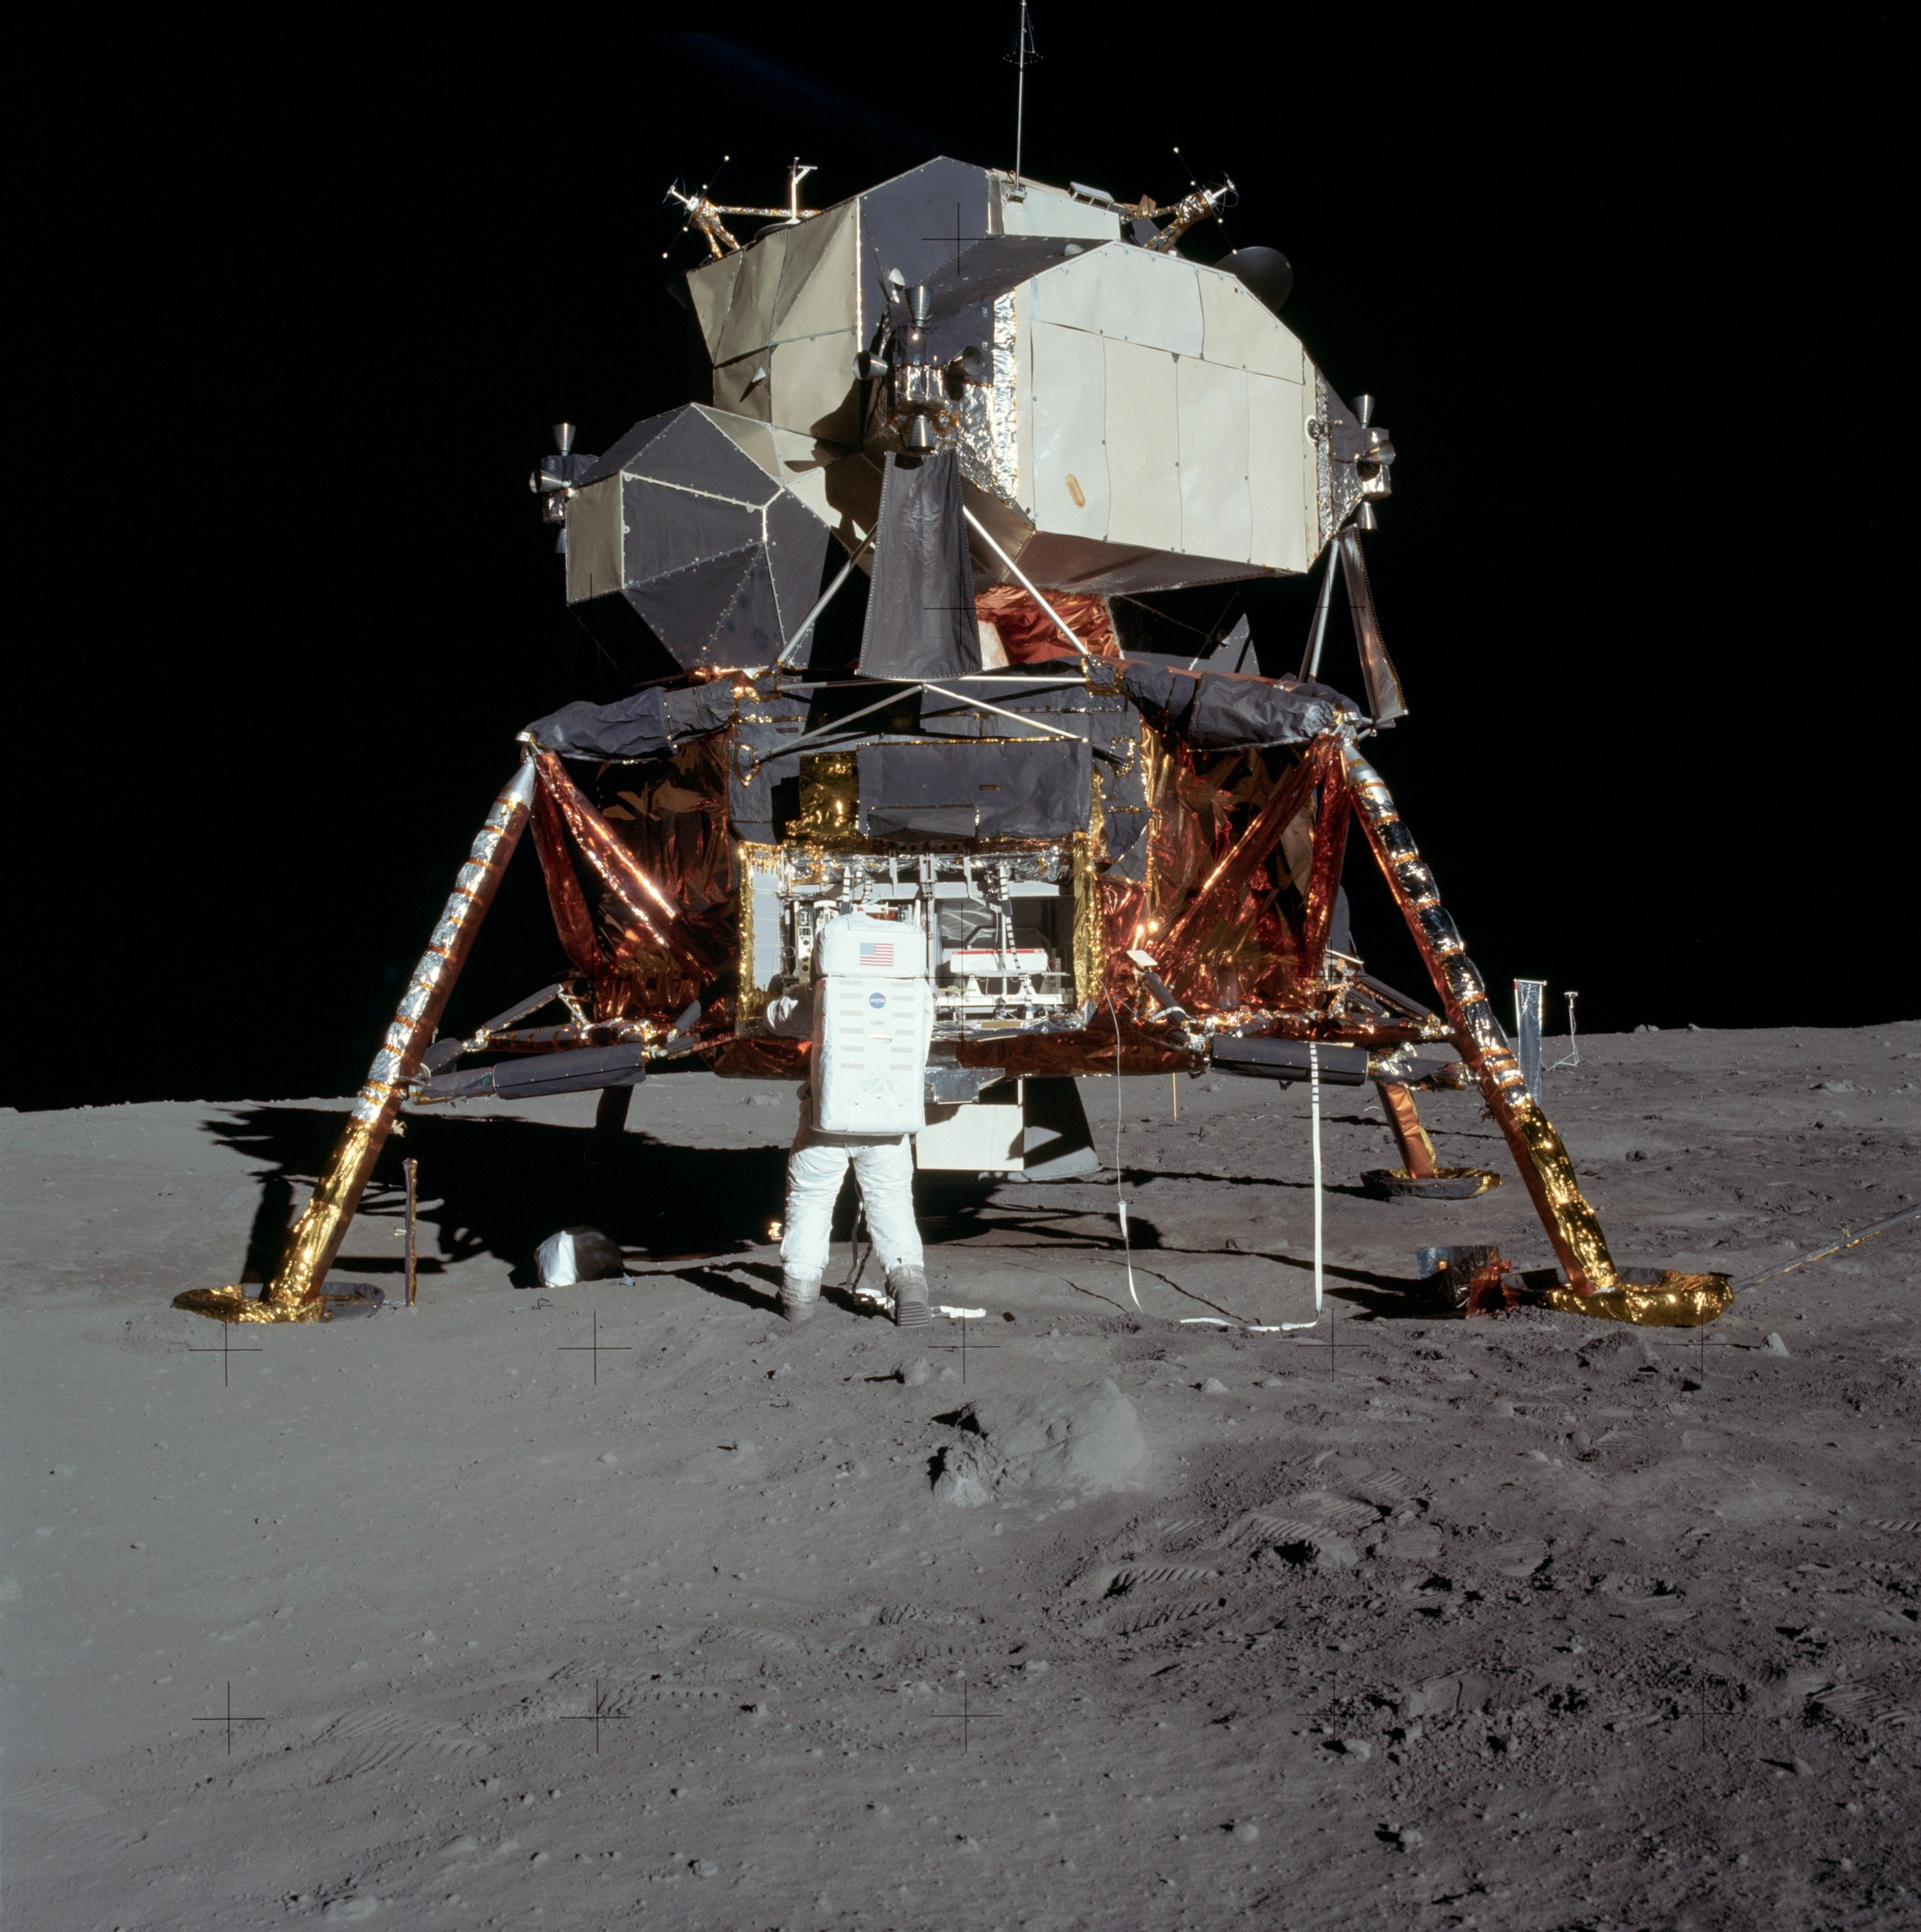


Image Analysis:
1) What is shown in the image?
- A lunar lander on the Moon’s surface, with an astronaut in a spacesuit standing near it.

2) What spacecraft or equipment can you identify?
- The Lunar Module (LM) descent stage with its boxy, panel-covered structure and four landing legs wrapped in foil.
- An astronaut in a white Extravehicular Mobility Unit (EMU) suit.
- Gold-colored foil insulation on parts of the lander and some nearby hardware.

3) What can you tell about the environment or terrain?
- It’s the Moon: a dusty, gray, rock-strewn regolith surface with no atmosphere, backlit by the Sun, and a black sky. The surface shows footprints and cratering, indicating low gravity and a vacuum environment.

4) What mission is this likely from?
- It appears to be from the Apollo lunar-landing era. The setup is consistent with an Apollo Lunar Module on the Moon with an astronaut EVA. If you had to name one mission, Apollo 11 (the Eagle landing) is the most famous example, though simi

In [17]:
import requests
import base64

# Download the image (Wikimedia blocks direct access from OpenAI servers)
image_url = "https://upload.wikimedia.org/wikipedia/commons/0/04/Apollo_11_Lunar_Lander_-_5927_NASA.jpg"
headers = {"User-Agent": "Mozilla/5.0"}  # Wikimedia requires a User-Agent header
image_data = requests.get(image_url, headers=headers).content
base64_image = base64.b64encode(image_data).decode("utf-8")

print(f"Image downloaded: {len(image_data) / 1024:.0f} KB")
from IPython.display import Image, display

display(Image(data=image_data))

# Analyze the image
response = client.responses.create(
    model="gpt-5-nano",
    input=[
        {
            "role": "user",
            "content": [
                {
                    "type": "input_text",
                    "text": """Analyze this NASA space photo:
1. What is shown in the image?
2. What spacecraft or equipment can you identify?
3. What can you tell about the environment or terrain?
4. What mission is this likely from?"""
                },
                {
                    "type": "input_image",
                    "image_url": f"data:image/jpeg;base64,{base64_image}"
                }
            ]
        }
    ]
)

print("\nImage Analysis:")
print("=" * 60)
print(response.output_text)
print("=" * 60)
print(f"\nTokens used: {response.usage.total_tokens}")

## Best Practices Summary

### 1. Content Safety
- ✅ **Always use moderation for user-generated content**
- ✅ Check moderation BEFORE sending to other APIs
- ✅ It's FREE - use it liberally!

### 2. Model Selection
- ✅ **Choose the cheapest model that meets your needs**
  - Text: `gpt-5-nano` for most tasks (uses Responses API)
  - Audio TTS: `tts-1` (not `tts-1-hd`)
  - Images: `dall-e-3` for high quality, `dall-e-2` for cost savings
  - Vision: `gpt-5-nano` (cost-efficient, sufficient for most vision tasks)
- ✅ Only upgrade to premium models when quality difference matters

### 3. API Usage for gpt-5-nano
- ✅ **Use the Responses API**: `client.responses.create()`
- ✅ **Access output correctly**: `response.output_text`
- ✅ **Control verbosity**: Use `text={"verbosity": "low|medium|high"}`
  - "low": Brief responses, saves tokens
  - "medium": Balanced (default)
  - "high": Detailed, comprehensive responses

### 4. Image Generation with DALL-E 3
- ✅ **Remember n=1 limitation**: DALL-E 3 only generates 1 image per request
- ✅ **Use quality wisely**: "standard" for most cases, "hd" only when needed
- ✅ **Choose appropriate style**: "vivid" for graphics, "natural" for realistic images
- ✅ **Check revised_prompt**: See how DALL-E 3 enhanced your prompt

### 5. Error Handling
- ✅ **Always use try/except blocks**
- ✅ Handle rate limits gracefully
- ✅ Provide helpful error messages to users
- ✅ Log errors for debugging

### 6. Security
- ✅ **NEVER hardcode API keys in production**
- ✅ Use environment variables or secrets management
- ✅ Rotate API keys periodically
- ✅ Set up usage alerts in OpenAI dashboard

### 7. Monitoring
- ✅ **Track your API usage regularly**
- ✅ Set up billing alerts
- ✅ Monitor which endpoints cost the most
- ✅ Review and optimize high-usage areas

### 8. Prompt Engineering
- ✅ Be specific about what you want
- ✅ Include system instructions directly in the input
- ✅ Provide examples when helpful
- ✅ Iterate and improve prompts based on results

### 9. Model-Specific Settings
- ✅ `gpt-5-nano` uses the **Responses API**:
  ```python
  response = client.responses.create(
      model="gpt-5-nano",
      input="your prompt here",
      text={"verbosity": "high"}
  )
  output = response.output_text
  ```
- ✅ Much cheaper than gpt-4o
- ✅ DALL-E 3 provides automatic prompt enhancement via `revised_prompt`

---



# Mini-Project: Support Ticket Analyzer

## Project Description

Let's combine everything we've learned! We'll build a **Support Ticket Analyzer** that:

1. **Checks if the ticket content is appropriate** (Moderation)
2. **Analyzes the urgency and issue type** (Text Generation)
3. **Drafts a professional response** (Text Generation)

This is a practical tool you could adapt for real IT support workflows!

---

## Try It Yourself First

Try to complete the function below on your own. Fill in the TODO sections using what you've learned.

In [18]:
def analyze_support_ticket_TODO(ticket_content):
    """
    Analyze a support ticket and generate a response.

    Args:
        ticket_content (str): The customer's ticket message

    Returns:
        dict: Analysis results including safety check, urgency, issue type, and draft response
    """

    # TODO 1: Check content safety with moderation API
    # Hint: Use client.moderations.create()
    # Store result in a variable called 'is_safe'

    # If content is not safe, return early
    # if not is_safe:
    #     return {"is_safe": False, "message": "Inappropriate content detected"}

    # TODO 2: Analyze ticket urgency and issue type
    # Create a prompt that asks the AI to identify:
    #   - Urgency level (Low, Medium, High, Critical)
    #   - Issue type (Hardware, Software, Network, Access, Other)
    # Hint: Use client.responses.create() with a good system prompt

    # TODO 3: Generate a professional response
    # Create another AI call to draft a response to the customer
    # The response should be:
    #   - Professional and empathetic
    #   - Address the specific issue mentioned
    #   - Provide clear next steps

    return {
        "is_safe": True,  # Replace with actual result
        "urgency": "TODO",
        "issue_type": "TODO",
        "draft_response": "TODO"
    }

print("TODO: Complete the function above, then test it with the test cases below!")

TODO: Complete the function above, then test it with the test cases below!


## Complete Solution

Here's a full implementation of the support ticket analyzer:

In [19]:
def analyze_support_ticket(ticket_content):
    """
    Analyze a support ticket and generate a response.

    Args:
        ticket_content (str): The customer's ticket message

    Returns:
        dict: Analysis results including safety check, urgency, issue type, and draft response
    """

    try:
        # Step 1: Check content safety
        print("🔍 Checking content safety...")
        moderation_response = client.moderations.create(input=ticket_content)
        is_safe = not moderation_response.results[0].flagged

        if not is_safe:
            flagged_categories = [
                category for category, flagged
                in moderation_response.results[0].categories
                if flagged
            ]
            return {
                "is_safe": False,
                "flagged_categories": flagged_categories,
                "message": "⚠️ Inappropriate content detected. Ticket requires manual review."
            }

        print("✅ Content is safe\n")

        # Step 2: Analyze urgency and issue type
        print("Analyzing urgency and issue type...")
        analysis_prompt = f"""You are an IT ticket classification assistant. Be concise.

Analyze this support ticket and provide:
1. Urgency level: Critical / High / Medium / Low
2. Issue type: Hardware / Software / Network / Access / Account / Other

Provide your response in this exact format:
Urgency: [level]
Issue Type: [type]

Ticket: {ticket_content}
"""

        analysis_response = client.responses.create(
            model=OPENAI_MODEL,
            input=analysis_prompt,
            text={"verbosity": "low"}  # Low verbosity for classification
        )

        analysis_text = analysis_response.output_text

        # Parse the response
        urgency = "Medium"  # Default
        issue_type = "Other"  # Default

        for line in analysis_text.split('\n'):
            if 'urgency:' in line.lower():
                urgency = line.split(':')[1].strip()
            elif 'issue type:' in line.lower():
                issue_type = line.split(':')[1].strip()

        print(f"  Urgency: {urgency}")
        print(f"  Issue Type: {issue_type}\n")

        # Step 3: Generate professional response
        print("Drafting response...")
        response_prompt = f"""You are a helpful IT support professional.

Draft a professional IT support response to this ticket.

Guidelines:
- Be empathetic and professional
- Acknowledge the issue
- Provide clear troubleshooting steps or next actions
- Include estimated response time if urgent
- Keep it concise (3-4 short paragraphs)

Ticket urgency: {urgency}
Issue type: {issue_type}

Ticket content: {ticket_content}
"""

        response_generation = client.responses.create(
            model=OPENAI_MODEL,
            input=response_prompt,
            text={"verbosity": "high"}
        )

        draft_response = response_generation.output_text

        print("✅ Analysis complete!\n")

        return {
            "is_safe": True,
            "urgency": urgency,
            "issue_type": issue_type,
            "draft_response": draft_response,
            "success": True
        }

    except Exception as e:
        return {
            "success": False,
            "error": str(e),
            "message": f"❌ Error analyzing ticket: {str(e)}"
        }

print("✅ Support Ticket Analyzer function created!")

✅ Support Ticket Analyzer function created!


##  Test Cases

Let's test the analyzer with different types of tickets:

### Test 1: Urgent Password Reset Request

In [20]:
test_ticket_1 = """
I've been locked out of my account and can't reset my password!
The password reset link isn't working and I have an important
presentation in 1 hour. I really need access ASAP!
"""

print("=" * 70)
print("TEST 1: Urgent Password Reset")
print("=" * 70)
print(f"\n Ticket Content:\n{test_ticket_1}\n")

result = analyze_support_ticket(test_ticket_1)

if result['success']:
    print("=" * 70)
    print(" ANALYSIS RESULTS")
    print("=" * 70)
    print(f"Safe: {result['is_safe']}")
    print(f"Urgency: {result['urgency']}")
    print(f"Issue Type: {result['issue_type']}")
    print(f"\n DRAFT RESPONSE:")
    print("-" * 70)
    print(result['draft_response'])
    print("-" * 70)
else:
    print(result['message'])

TEST 1: Urgent Password Reset

 Ticket Content:

I've been locked out of my account and can't reset my password!
The password reset link isn't working and I have an important
presentation in 1 hour. I really need access ASAP!


🔍 Checking content safety...


✅ Content is safe

Analyzing urgency and issue type...


  Urgency: Critical
  Issue Type: Account

Drafting response...


✅ Analysis complete!

 ANALYSIS RESULTS
Safe: True
Urgency: Critical
Issue Type: Account

 DRAFT RESPONSE:
----------------------------------------------------------------------
Hi there,

I’m sorry you’re locked out and the reset link isn’t working—especially with an important presentation coming up. This is a high-priority issue, and I’ll treat it as urgent to get you back in as soon as possible.

To restore access quickly, please reply with your account username (and domain if applicable) and the recovery contact on file (alternate email or mobile). If you have secure verification ready, you can share it via this ticket. Our on‑call identity admin will perform an emergency password reset, unlock the account, and issue a temporary password that you must change on first login, while also verifying your MFA setup to prevent another lockout.

In the meantime, you can try these quick checks: attempt the reset from a different browser or device, clear your browser cache, and double-check 

### Test 2: General Software Question

In [21]:
test_ticket_2 = """
Hi, I'm trying to understand how to use the shared calendar feature
in Outlook. Can someone explain how to share my calendar with my team
and set the appropriate permissions? Thanks!
"""

print("=" * 70)
print("TEST 2: General Software Question")
print("=" * 70)
print(f"\n📝 Ticket Content:\n{test_ticket_2}\n")

result = analyze_support_ticket(test_ticket_2)

if result['success']:
    print("=" * 70)
    print(" ANALYSIS RESULTS")
    print("=" * 70)
    print(f"Safe: {result['is_safe']}")
    print(f"Urgency: {result['urgency']}")
    print(f"Issue Type: {result['issue_type']}")
    print(f"\n DRAFT RESPONSE:")
    print("-" * 70)
    print(result['draft_response'])
    print("-" * 70)
else:
    print(result['message'])

TEST 2: General Software Question

📝 Ticket Content:

Hi, I'm trying to understand how to use the shared calendar feature
in Outlook. Can someone explain how to share my calendar with my team
and set the appropriate permissions? Thanks!


🔍 Checking content safety...


✅ Content is safe

Analyzing urgency and issue type...


  Urgency: Low
  Issue Type: Software

Drafting response...


✅ Analysis complete!

 ANALYSIS RESULTS
Safe: True
Urgency: Low
Issue Type: Software

 DRAFT RESPONSE:
----------------------------------------------------------------------
Thanks for reaching out. I understand you want to share your Outlook calendar with your team and set the right permissions. I’ll outline the steps for both Outlook on the web and the desktop app. This is a low-priority request, so you can expect a reply within 1 business day.

Outlook on the web (Office 365 / Outlook.com):
- Open Calendar and select Share (next to your calendar).
- Enter your team members’ email addresses and choose a permission level:
  - Can view when I’m busy
  - Can view titles and locations
  - Can view all details
  - Can edit
- Send the invitation. Recipients will get an email to access your calendar.

Outlook desktop (Windows or Mac):
- Go to Calendar view, then Home > Share Calendar (or Share > Calendar, depending on version).
- Add the person’s name or email and select the desired permiss

### Test 3: Frustrated User (Professional but Upset)

In [22]:
test_ticket_3 = """
This is the third time this month the VPN has gone down! I'm trying to
work from home and I can't access any company resources. This is extremely
frustrating and affecting my productivity. When will this be fixed properly?
"""

print("=" * 70)
print("TEST 3: Frustrated User")
print("=" * 70)
print(f"\n📝 Ticket Content:\n{test_ticket_3}\n")

result = analyze_support_ticket(test_ticket_3)

if result['success']:
    print("=" * 70)
    print(" ANALYSIS RESULTS")
    print("=" * 70)
    print(f"Safe: {result['is_safe']}")
    print(f"Urgency: {result['urgency']}")
    print(f"Issue Type: {result['issue_type']}")
    print(f"\n DRAFT RESPONSE:")
    print("-" * 70)
    print(result['draft_response'])
    print("-" * 70)
else:
    print(result['message'])

TEST 3: Frustrated User

📝 Ticket Content:

This is the third time this month the VPN has gone down! I'm trying to
work from home and I can't access any company resources. This is extremely
frustrating and affecting my productivity. When will this be fixed properly?


🔍 Checking content safety...


✅ Content is safe

Analyzing urgency and issue type...


  Urgency: Critical
  Issue Type: Network

Drafting response...


✅ Analysis complete!

 ANALYSIS RESULTS
Safe: True
Urgency: Critical
Issue Type: Network

 DRAFT RESPONSE:
----------------------------------------------------------------------
I’m sorry you’re dealing with another VPN outage, and I know how critical this is for your work from home. I’ve treated this as a Critical network incident and have escalated it to Network Operations for immediate attention.

To help us diagnose quickly, please reply with your device OS (Windows/macOS/Linux), the VPN client and version you’re using, and any error message you see. If possible, note the last time you were able to connect. In the meantime, you can try basic checks: confirm you have internet access, restart the VPN client, and if you can, test a connection from a different network (for example a mobile hotspot) or a different VPN gateway/server.

We’ll provide an initial update within 15 minutes and, if this is a broader outage, expect restoration within 2-4 hours. We’ll keep you posted every 30 mi

---

# Error Handling Reference

Here are common errors you might encounter and how to handle them:

---

## Common Error Types

The function below demonstrates a production-ready approach to API calls. It catches specific OpenAI error types (rate limits, authentication, API errors) and handles each one differently. For example, rate limit errors trigger an automatic retry with **exponential backoff** (waiting 1s, then 2s, then 4s), while authentication errors return immediately since retrying won't help.

In [23]:
from openai import OpenAIError, RateLimitError, APIError, AuthenticationError

def make_robust_api_call(prompt, max_retries=3):
    """
    Make an API call with comprehensive error handling.

    Args:
        prompt (str): The prompt to send
        max_retries (int): Maximum number of retry attempts

    Returns:
        dict: Response or error information
    """
    import time

    for attempt in range(max_retries):
        try:
            response = client.responses.create(
                model=OPENAI_MODEL,
                input=prompt,
                text={"verbosity": "high"}
            )

            return {
                "success": True,
                "response": response.output_text
            }

        # Error 1: Rate Limit - Too many requests
        except RateLimitError as e:
            wait_time = 2 ** attempt  # Exponential backoff: 1s, 2s, 4s...
            print(f"⚠️ Rate limit hit. Waiting {wait_time} seconds...")
            if attempt < max_retries - 1:
                time.sleep(wait_time)
                continue
            return {
                "success": False,
                "error_type": "rate_limit",
                "message": "Rate limit exceeded. Please try again later."
            }

        # Error 2: Authentication - Invalid API key
        except AuthenticationError as e:
            return {
                "success": False,
                "error_type": "authentication",
                "message": "Invalid API key. Please check your credentials."
            }

        # Error 3: API Error - OpenAI service issues
        except APIError as e:
            print(f"⚠️ API error occurred: {str(e)}")
            if attempt < max_retries - 1:
                time.sleep(2)
                continue
            return {
                "success": False,
                "error_type": "api_error",
                "message": f"OpenAI API error: {str(e)}"
            }

        # Error 4: Any other errors
        except Exception as e:
            return {
                "success": False,
                "error_type": "unknown",
                "message": f"Unexpected error: {str(e)}"
            }

    return {
        "success": False,
        "error_type": "max_retries",
        "message": "Maximum retry attempts exceeded."
    }

print("✅ Robust API call function created!")
print("\nThis function handles:")
print("  1. Rate limits with exponential backoff")
print("  2. Authentication errors")
print("  3. API service errors")
print("  4. Unknown errors")
print("  5. Automatic retries")

✅ Robust API call function created!

This function handles:
  1. Rate limits with exponential backoff
  2. Authentication errors
  3. API service errors
  4. Unknown errors
  5. Automatic retries


## Test the Error Handling

In [24]:
# Test with a normal request
result = make_robust_api_call("What is an IP address?")

if result['success']:
    print("✅ Success!")
    print(f"Response: {result['response']}")
else:
    print(f"❌ Error ({result['error_type']}): {result['message']}")

✅ Success!
Response: An IP address is a numerical label assigned to each device that connects to a computer network (like the internet). It acts like a mailing address so data can be sent to the right place.

Key points:
- Formats:
  - IPv4: four decimal numbers (0–255) separated by dots, e.g., 192.168.1.42
  - IPv6: eight groups of four hexadecimal digits separated by colons, e.g., 2001:0db8:85a3:0000:0000:8a2e:0370:7334
- What it does:
  - Identifies a device on a network and provides a route for data to reach that device.
  - Packets on the network carry the destination IP so routers know where to send them.
- Types you’ll hear about:
  - Public vs private: public IPs are routable on the internet; private IPs are used inside local networks (e.g., 192.168.x.x, 10.x.x.x, 172.16–31.x.x).
  - Dynamic vs static: dynamic IPs can change over time (often assigned by DHCP); static IPs don’t change.
  - Loopback: 127.0.0.1 (IPv4) or ::1 (IPv6) refers to your own device.
- How it’s used:
  - A

##  Error Reference Table

| Error Type | Common Cause | Solution |
|------------|--------------|----------|
| **Rate Limit** | Too many requests per minute | Implement exponential backoff, reduce request frequency |
| **Authentication** | Invalid/expired API key | Check API key, regenerate if needed |
| **Model Not Found** | Typo in model name | Verify model name matches OpenAI docs |
| **Output Too Long** | Response exceeds limits | Use verbosity "low" or "medium", or set max_output_tokens |
| **Timeout** | Request took too long | Increase timeout, check network connection |
| **Invalid Request** | Missing required parameters | Check API documentation for required fields |
| **Content Policy** | Violated OpenAI policies | Use moderation API first, adjust content |

---



## Additional Resources

- **OpenAI Cookbook**: https://cookbook.openai.com
- **API Reference**: https://platform.openai.com/docs/api-reference
- **Pricing**: https://openai.com/pricing